In [1]:
import matplotlib.pyplot as plt
import numpy as np

from testbed import Bandit

%load_ext autoreload
%autoreload 2

## Initialize a specific 10-armed bandit

In [2]:
bandit_object = Bandit(10)

In [3]:
bandit_object._vals

array([ 0.30471708, -1.03998411,  0.7504512 ,  0.94056472, -1.95103519,
       -1.30217951,  0.1278404 , -0.31624259, -0.01680116, -0.85304393])

In [4]:
bandit = bandit_object.reward

In [5]:
[bandit(a) for a in range(0,10)]

[1.1841150546172599,
 -0.2621921708115472,
 0.8164818933676733,
 2.0678059233592467,
 -1.4835258464017909,
 -2.1614719697455564,
 0.49659118724978424,
 -1.275125193172581,
 0.8616491438029837,
 -0.9029698385598329]

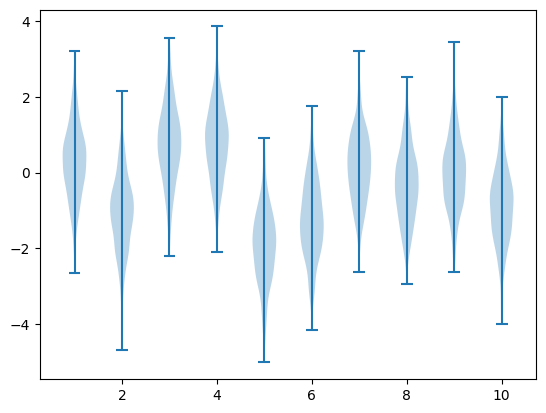

In [6]:
rewards = [[bandit(a) for r in range(0, 500)] for a in range(0,10)]

plt.violinplot(rewards);

## $\epsilon$-greedy action-value method

In [25]:
def bandit_algo_run(bandit, k, T, epsilon):
    """
    Run the epsilon-greedy algorithm on a particular k-armed bandit for T time steps.
    
    Args:
        bandit: bandit reward function; bandit(a) returns a real number for every possible action a.
        k: number of arms in the bandit
        T: number of timesteps played
        epsilon: probability with which an exploratory action is taken
    """

    n = np.zeros(k)              # number of times each action was taken (k,)
    rewards = []                 # sequence of rewards received (T,)
    q_estimates = np.zeros(k)    # values estimates for each action at every step (k,)
    
    for t in range(0,T):
        # Determine greedy action, randomly breaking ties randomly
        greedy_actions = np.flatnonzero(q_estimates == q_estimates.max())
        greedy_action = np.random.choice(greedy_actions)
        
        # Determine exploratory action randomly
        exploratory_action = np.random.choice(range(0,10))
        exploratory_action
        
        # Choose eploratory action with epsilon probability, and the greedy actio otherwise
        a = np.random.choice([greedy_action, exploratory_action], p=[1-epsilon, epsilon])
        
        # Determine reward for the chosen action
        r = bandit(a)
        rewards.append(r)
        
        # Update value estimates
        n[a] += 1
        q_estimates[a] += (r - q_estimates[a])/n[a]
    
    return rewards

In [85]:
def simulate(k, T, epsilon, R):
    """
    Run R runs of the epsilon-greedy algorithm on R different k-armed bandits for T time steps, and average the rewards from all runs for each time step.

    Args:
        k: number of arms in the bandit
        T: number of timesteps played
        epsilon: probability with which an exploratory action is taken
        R: number of runs
    """

    average_rewards = np.zeros(T)
    
    for r in range(0,R):
        bandit = Bandit(k).reward
        rewards = bandit_algo_run(bandit, k, T, epsilon)
        average_rewards = average_rewards + 1/(r+1)*(rewards - average_rewards)

    return average_rewards

In [128]:
# Run 2000 runs for three different vaues of epsilon

k = 10                         # number of arms in the bandit
T = 1000                       # number of timesteps played
epsilons = [0.0, 0.01, 0.1]
R = 2000                       # number of runs to play in the simulation

average_rewards = [simulate(k, T, epsilon, R) for epsilon in epsilons]
average_rewards = np.array(average_rewards)

print("Average reward: ", np.mean(average_rewards, axis=1))

Average reward:  [1.02641544 1.18872706 1.29830614]


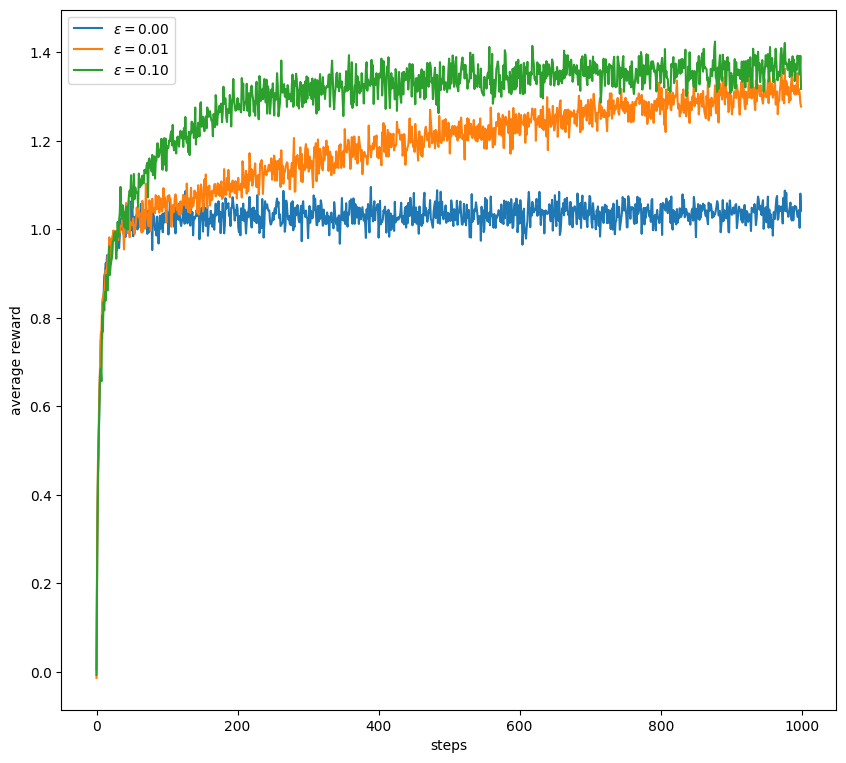

In [129]:
plt.figure(figsize=(10, 20))

plt.subplot(2, 1, 1)
for i, epsilon in enumerate(epsilons):
    plt.plot(average_rewards[i], label='$\\epsilon = %.02f$' % (epsilon))
plt.xlabel('steps')
plt.ylabel('average reward')
plt.legend()